### ME vs SCIKIT-LEARN (SVM Classifier and Regressor)

In this notebook, we benchmark our custom SVM implementation against the industry-standard Scikit-Learn library using real-world datasets.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error

# Import custom implementations
from svm_classifier import MySVMClassifier
from svm_regressor import MySVMRegressor

# Import Sklearn implementations\n
from sklearn.svm import SVC, SVR

## 1. Classification: Breast Cancer Dataset
Binary classification task to diagnose breast cancer (Malignant vs. Benign).

In [ ]:
# Load Data
data = datasets.load_breast_cancer()
X, y = data.data, data.target

# Convert 0/1 to -1/1 for our Custom SVM
y_custom = np.where(y == 0, -1, 1)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
_, _, y_train_custom, y_test_custom = train_test_split(X, y_custom, test_size=0.2, random_state=42)

# Scale (Crucial for Gradient Descent)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Train Custom Model ---
print("Training Custom SVM Classifier...")
clf = MySVMClassifier(learning_rate=0.001, lambda_param=0.01, n_iterations=1000)
clf.fit(X_train, y_train_custom)
custom_preds = clf.predict(X_test)

# --- Train Sklearn Model ---
print("Training Sklearn SVC...")
sk_clf = SVC(kernel='linear', C=1.0) # Using linear kernel to match our linear implementation
sk_clf.fit(X_train, y_train)
sk_preds = sk_clf.predict(X_test)

# --- Compare ---
print("\n--- Classification Results ---")
acc_custom = accuracy_score(y_test_custom, custom_preds)
acc_sklearn = accuracy_score(y_test, sk_preds)

print(f"Custom Accuracy: {acc_custom:.4f}")
print(f"Sklearn Accuracy: {acc_sklearn:.4f}")
if abs(acc_custom - acc_sklearn) < 0.05:
    print("✅ Success! Performance is comparable.")
else:
    print("⚠️ Difference detected. Tuning hyperparameters might be needed.")

Training Custom SVM Classifier...
Training Sklearn SVC...

--- Classification Results ---
Custom Accuracy: 0.9825
Sklearn Accuracy: 0.9561
✅ Success! Performance is comparable.


## 2. Regression: California Housing Dataset
Predicting housing prices based on features like median income and house age.

Training Custom SVM Regressor...
Training Sklearn SVR...

--- Regression Results ---
Custom MSE: 0.2039
Sklearn MSE: 0.2030


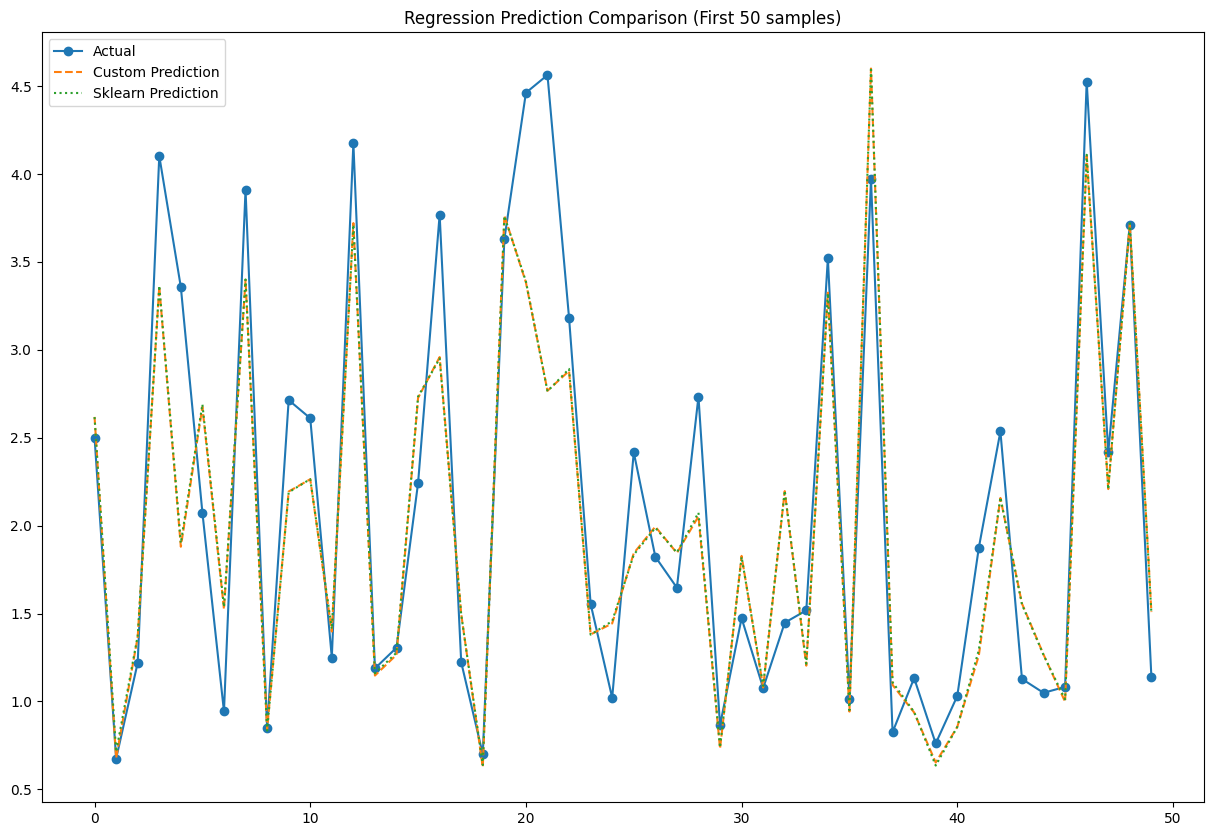

In [6]:
# Load Data (Using subset for speed)
data_reg = datasets.fetch_california_housing()
X_reg, y_reg = data_reg.data[:500], data_reg.target[:500]

# Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scale
scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)

# --- Train Custom Regressor ---
print("Training Custom SVM Regressor...")
reg = MySVMRegressor(learning_rate=0.001, lambda_param=0.01, n_iterations=2000, epsilon=0.1)
reg.fit(X_train_r, y_train_r)
custom_preds_r = reg.predict(X_test_r)

# --- Train Sklearn Regressor ---
print("Training Sklearn SVR...")
sk_reg = SVR(kernel='linear', C=1.0, epsilon=0.1)
sk_reg.fit(X_train_r, y_train_r)
sk_preds_r = sk_reg.predict(X_test_r)

# --- Compare ---
print("\n--- Regression Results ---")
mse_custom = mean_squared_error(y_test_r, custom_preds_r)
mse_sklearn = mean_squared_error(y_test_r, sk_preds_r)

print(f"Custom MSE: {mse_custom:.4f}")
print(f"Sklearn MSE: {mse_sklearn:.4f}")

# Visual Comparison (First 50 points)
plt.figure(figsize=(15, 10))
plt.plot(y_test_r[:50], label='Actual', marker='o')
plt.plot(custom_preds_r[:50], label='Custom Prediction', linestyle='--')
plt.plot(sk_preds_r[:50], label='Sklearn Prediction', linestyle=':')
plt.title("Regression Prediction Comparison (First 50 samples)")
plt.legend()
plt.show()